In [1]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import torchode

from scipy.integrate import solve_ivp as sp_solve_ivp

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

import torch
import torch.nn as nn
device='cpu'

# from ftnode.utils import set_global_seed

# seed = 1234
# set_global_seed(seed = seed)
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [2]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims = [2,20,20,20,2],
    lower_bound = -10,
    upper_bound =-0.1
)

g = GeluSigmoidMLP(
    dims = [6,20,20,20,2],
    lower_bound = -1,
    upper_bound = 8
)

model = FTNODE(f,g)

model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

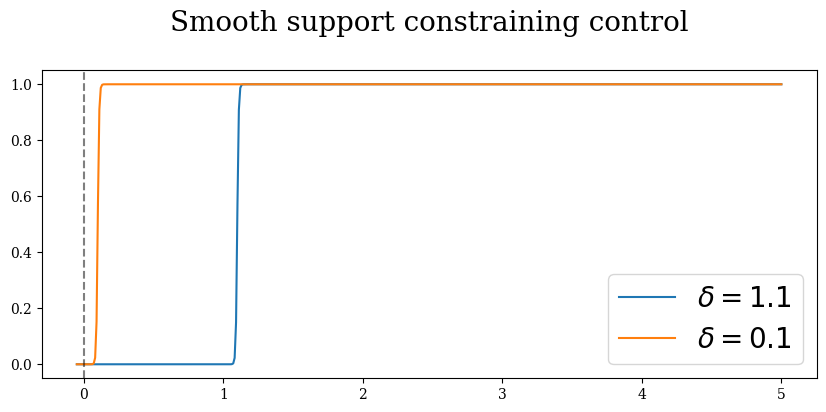

In [3]:
def H(x,gamma):
    return 1 / (1+np.exp(-gamma*x))

def phi(x,a,b,delta,gamma):
    return H(x-(a+delta),gamma) - H(x-(b-delta),gamma)

gamma = 200
delta_1 = 1.1
delta_0 = 0.1

x_lin = np.linspace(-0.05,5,501)
plt.figure(figsize=(10,4))
plt.title(
    "Smooth support constraining control" + "\n"
    # rf"$\gamma = {gamma}$, $\delta = {delta:.4f}$"
    ,fontsize=20
)
label1 = rf"$\delta = {delta_1}$"
label0 = rf"$\delta = {delta_0}$"
plt.plot(x_lin, H(x_lin-delta_1,gamma),label=label1)
plt.plot(x_lin, H(x_lin-delta_0,gamma),label=label0)
plt.axvline(0,linestyle='--', c='black', alpha=0.5)
plt.legend(fontsize=20)
plt.show()

In [6]:

def genetic_toggle_switch(state, t, alpha1, alpha2, beta, gamma_exp):
    """
    Computes derivatives for Equation 27 (Li & Lin, 2013).
    Renamed gamma -> gamma_exp to avoid confusion with the gamma used in u_prime H()
    """
    x1, x2 = state
    x1_safe = np.abs(x1)
    x2_safe = np.abs(x2)
    dx1dt = -x1 + alpha1 / (1 + x2_safe**beta)
    dx2dt = -x2 + alpha2 / (1 + x1_safe**gamma_exp)
    return np.array([dx1dt, dx2dt])

# --- Adapted Control Functions ---

def R(u, x, k, x_target):
    # Assumes g_eval works with multi-dim inputs (2D x, 4D u)
    for _ in range(k):
        x = g(x, u)
    return x - x_target

def u_prime(u, x, x_target, eta, k):
    # Note: Ensure 'H' and 'gamma' are defined globally or passed in
    # u is 4-dim: [alpha1, alpha2, beta, gamma]
    
    # 1. Masking / Constraints (from your snippet)
    phi_u1 = H(u[:2]-delta_0, gamma) 
    phi_u2 = H(u[2:]-delta_1, gamma)
    phi_u = np.hstack((phi_u1, phi_u2))

    # 2. Gradient Calculation
    u_tensor = torch.tensor(u, dtype=torch.float32, requires_grad=True)
    x_tensor = torch.tensor(x, dtype=torch.float32, requires_grad=False)
    x_target_tensor = torch.tensor(x_target, dtype=torch.float32, requires_grad=False)

    resid = torch.sum(R(u_tensor, x_tensor, k, x_target_tensor)**2)
    resid.backward()

    grad = u_tensor.grad.detach().numpy() # .detach() is safer
    
    return -eta * grad * phi_u

# --- Deterministic Controller ---

def genetic_toggle_control(t,xu,x_target,eta,k):
    x = xu[:2]
    u = xu[2:]
    a1,a2,b,gam = u
    # print(x,u)

    dxdt = genetic_toggle_switch(x,t,a1,a2,b,gam)
    dudt = u_prime(u,x,x_target,eta,k)

    return np.hstack([dxdt,dudt])

# --- SDE Functions ---

def make_drift_toggle(x_target, eta, k):
    """
    Drift for SDE: d[x,u] = drift(x,u,t)*dt + G*dW
    State xu is 6-dim: [x1, x2, alpha1, alpha2, beta, gamma]
    """
    def drift(xu, t):
        # 1. Unpack State
        x = xu[:2]  # Shape (2,)
        u = xu[2:]  # Shape (4,)

        # 2. Deterministic Dynamics (dx/dt)
        # u = [alpha1, alpha2, beta, gamma_exp]
        dxdt = genetic_toggle_switch(x, t, u[0], u[1], u[2], u[3])

        # 3. Control Dynamics (du/dt)
        dudt = u_prime(u, x, x_target, eta, k)

        # 4. Combine
        return np.concatenate([dxdt, dudt])

    return drift

def make_diffusion_toggle(scale):
    """
    Diffusion matrix G(x) for SDE.
    Returns a (6 x 2) matrix.
    We apply independent noise to x1 and x2.
    """
    def diffusion(xu, t):
        x = xu[:2]
        
        # Define noise intensity (Multiplicative noise example)
        # Result is shape (2,)
        sig = scale * np.sqrt(np.abs(x))

        # G must be (Num_States x Num_Noise_Sources) -> (6 x 2)
        # Cols correspond to dW1 and dW2
        G = np.zeros((6, 2))
        
        # d(x1) has noise from dW1
        G[0, 0] = sig[0] 
        # d(x2) has noise from dW2
        G[1, 1] = sig[1]
        
        # x3..x6 (the parameters u) have 0 diffusion (rows 2-5 are 0)
        
        return G

    return diffusion

# deterministic plot

In [7]:
seed = 99

rng = np.random.default_rng(seed=seed)

n_targets = 10
t=np.linspace(0,100,501)
x_targets = []

# create randomized targets

for idx in range(n_targets):
    u = rng.uniform(0,5,size=4)
    x0 = rng.uniform(0,6,size=2)

    sol = odeint(genetic_toggle_switch, x0,t,args=tuple(u))
    x_targets.append(sol[-1])


# solve feedback control

xu0 = np.array([3,3,3,3,3,3])

n_colloc = 501
t_max = 10
eta=1e0
k=1

Ts = []
Xs = []
Us = []
Xs_targets = []



for x_target in tqdm(x_targets):
    sol = sp_solve_ivp(
        genetic_toggle_control,
        t_span=[0,t_max],
        y0 = xu0,
        t_eval=np.linspace(0,t_max,n_colloc),
        args = (x_target,eta,k)
    )

    XU = sol.y
    X = XU[:2,:]
    U = XU[2:,:]
    xu0 = sol.y[:,-1]

    Ts.append(sol.t)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)


Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    # xi = Xs_targets[i]
    xi=Xs[i]
    
    # xi_scaled_tensor = torch.tensor(scaler.transform(xi.reshape(-1,1)),dtype=torch.float32).expand(n_colloc,1)
    xi_tensor = torch.tensor(xi.T,dtype=torch.float32)
    ui_tensor = torch.tensor(ui.T, dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_tensor, ui_tensor)
    
    Gs.append(gi)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

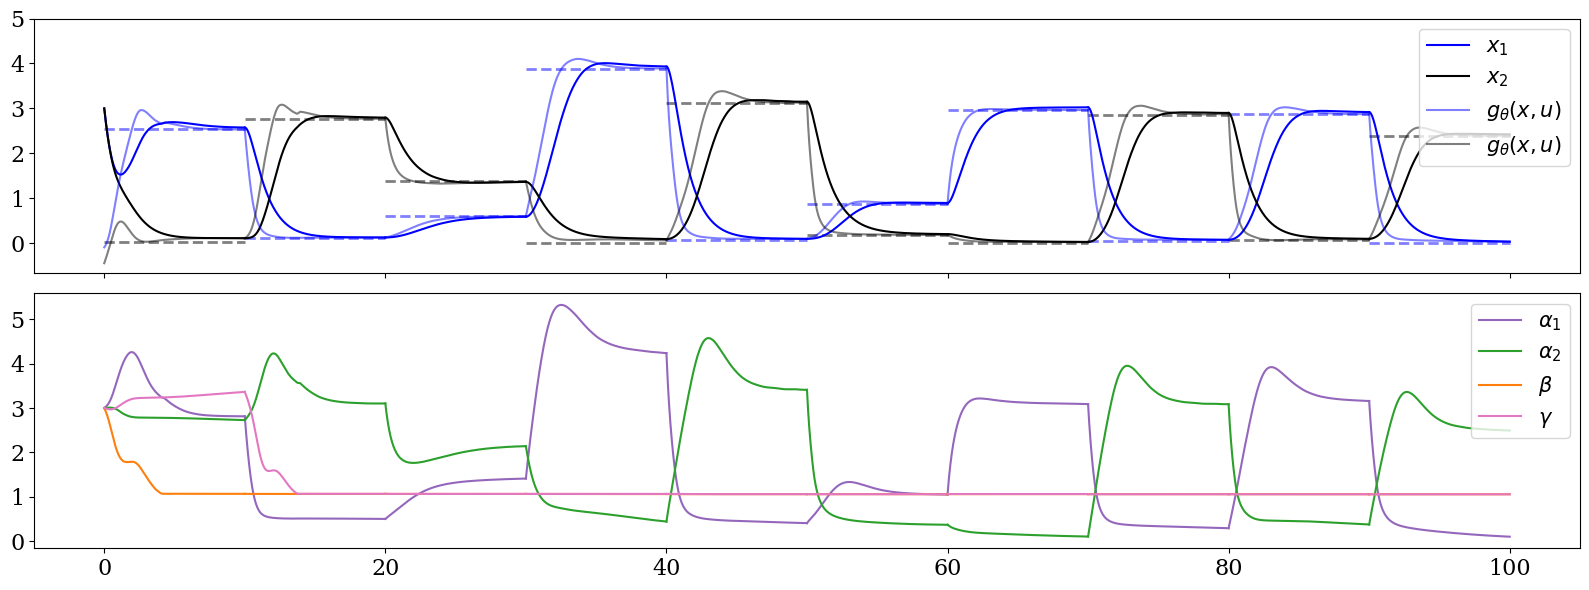

In [20]:
fig, axs = plt.subplots(2,1, figsize=(16,6),sharex =True)

axs = axs.flatten()

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    ax = axs[0]
    if idx == 0:
        ax.plot(ti, Xsi[0,:],c='blue',zorder=2, label=r"$x_1$")
        ax.plot(ti, Xsi[1,:],c='black',zorder=2,label=r"$x_2$")
        ax.plot(ti,Gsi[:,0],c='blue', alpha=0.5, label=r"$g_\theta(x,u)$")
        ax.plot(ti,Gsi[:,1],c='black', alpha=0.5,label=r"$g_\theta(x,u)$")
    else:
        ax.plot(ti, Xsi[0,:],c='blue',zorder=2, )
        ax.plot(ti, Xsi[1,:],c='black',zorder=2,)
        ax.plot(ti,Gsi[:,0],c='blue', alpha=0.5)
        ax.plot(ti,Gsi[:,1],c='black', alpha=0.5)

    ax.hlines(
        Xsi_target[0],
        xmin=ti[0],
        xmax=ti[-1],
        color='blue',
        alpha=0.5,
        linestyle='--',
        zorder=1,
        lw=2
    )

    ax.hlines(
        Xsi_target[1],
        xmin=ti[0],
        xmax=ti[-1],
        color='black',
        alpha=0.5,
        linestyle='--',
        zorder=1,
        lw=2
    )
    ax.legend(loc='upper right', fontsize=15)

    #control
    ax = axs[1]
    labs = [r"$\alpha_1$",r"$\alpha_2$",  r'$\beta$', r'$\gamma$']
    colors = ["purple", "tab:purple", "tab:green",'green']
    colors = ["tab:purple", "tab:green",'tab:orange',"tab:pink",]

    for in_idx, u in enumerate(Usi):
        if idx==0:
            ax.plot(ti,u,c=colors[in_idx],label=labs[in_idx])
        else:
            ax.plot(ti,u,c=colors[in_idx],)
        # print(u[-1])
        # print()
    ax.legend(loc='upper right', fontsize=15)

for ax in axs:
    
    # ax.set_xticks([0,1,2,3,4,5])
    ax.set_yticks([0,1,2,3,4,5])
    ax.tick_params(axis='both', which='major', labelsize=16, )
    # ax.grid(True)


plt.tight_layout()
plt.show()


    

# Noisy Targets

In [48]:
# in house sde solver
def itoint(drift_func, diff_func, y0, t_span, dW):
    """
    A simple Euler-Maruyama solver that accepts pre-generated noise.
    
    Args:
        drift_func: Function f(y, t) returning (d,)
        diff_func:  Function G(y, t) returning (d, m)
        y0:         Initial state (d,)
        t_span:     Time array (N,)
        dW:         Pre-calculated noise increments (N-1, m)
    
    Returns:
        Solution array of shape (N, d)
    """
    N = len(t_span)
    d = len(y0)
    
    # Pre-allocate solution array
    ys = np.zeros((N, d))
    ys[0] = y0
    
    curr_y = y0.copy()
    
    for i in range(N - 1):
        t = t_span[i]
        dt = t_span[i+1] - t
        
        # Get the specific noise increment for this step
        dw_step = dW[i]  # Shape (2,)
        
        # Evaluate dynamics
        f = drift_func(curr_y, t)   # Shape (6,)
        G = diff_func(curr_y, t)    # Shape (6, 2)
        
        # Euler-Maruyama Step: y += f*dt + G*dW
        # matrix multiplication: (6,2) @ (2,) -> (6,)
        diffusion_step = G @ dw_step 
        
        curr_y = curr_y + f * dt + diffusion_step
        curr_y[:2] = np.maximum(curr_y[:2], 0)
        ys[i+1] = curr_y
        
    return ys

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

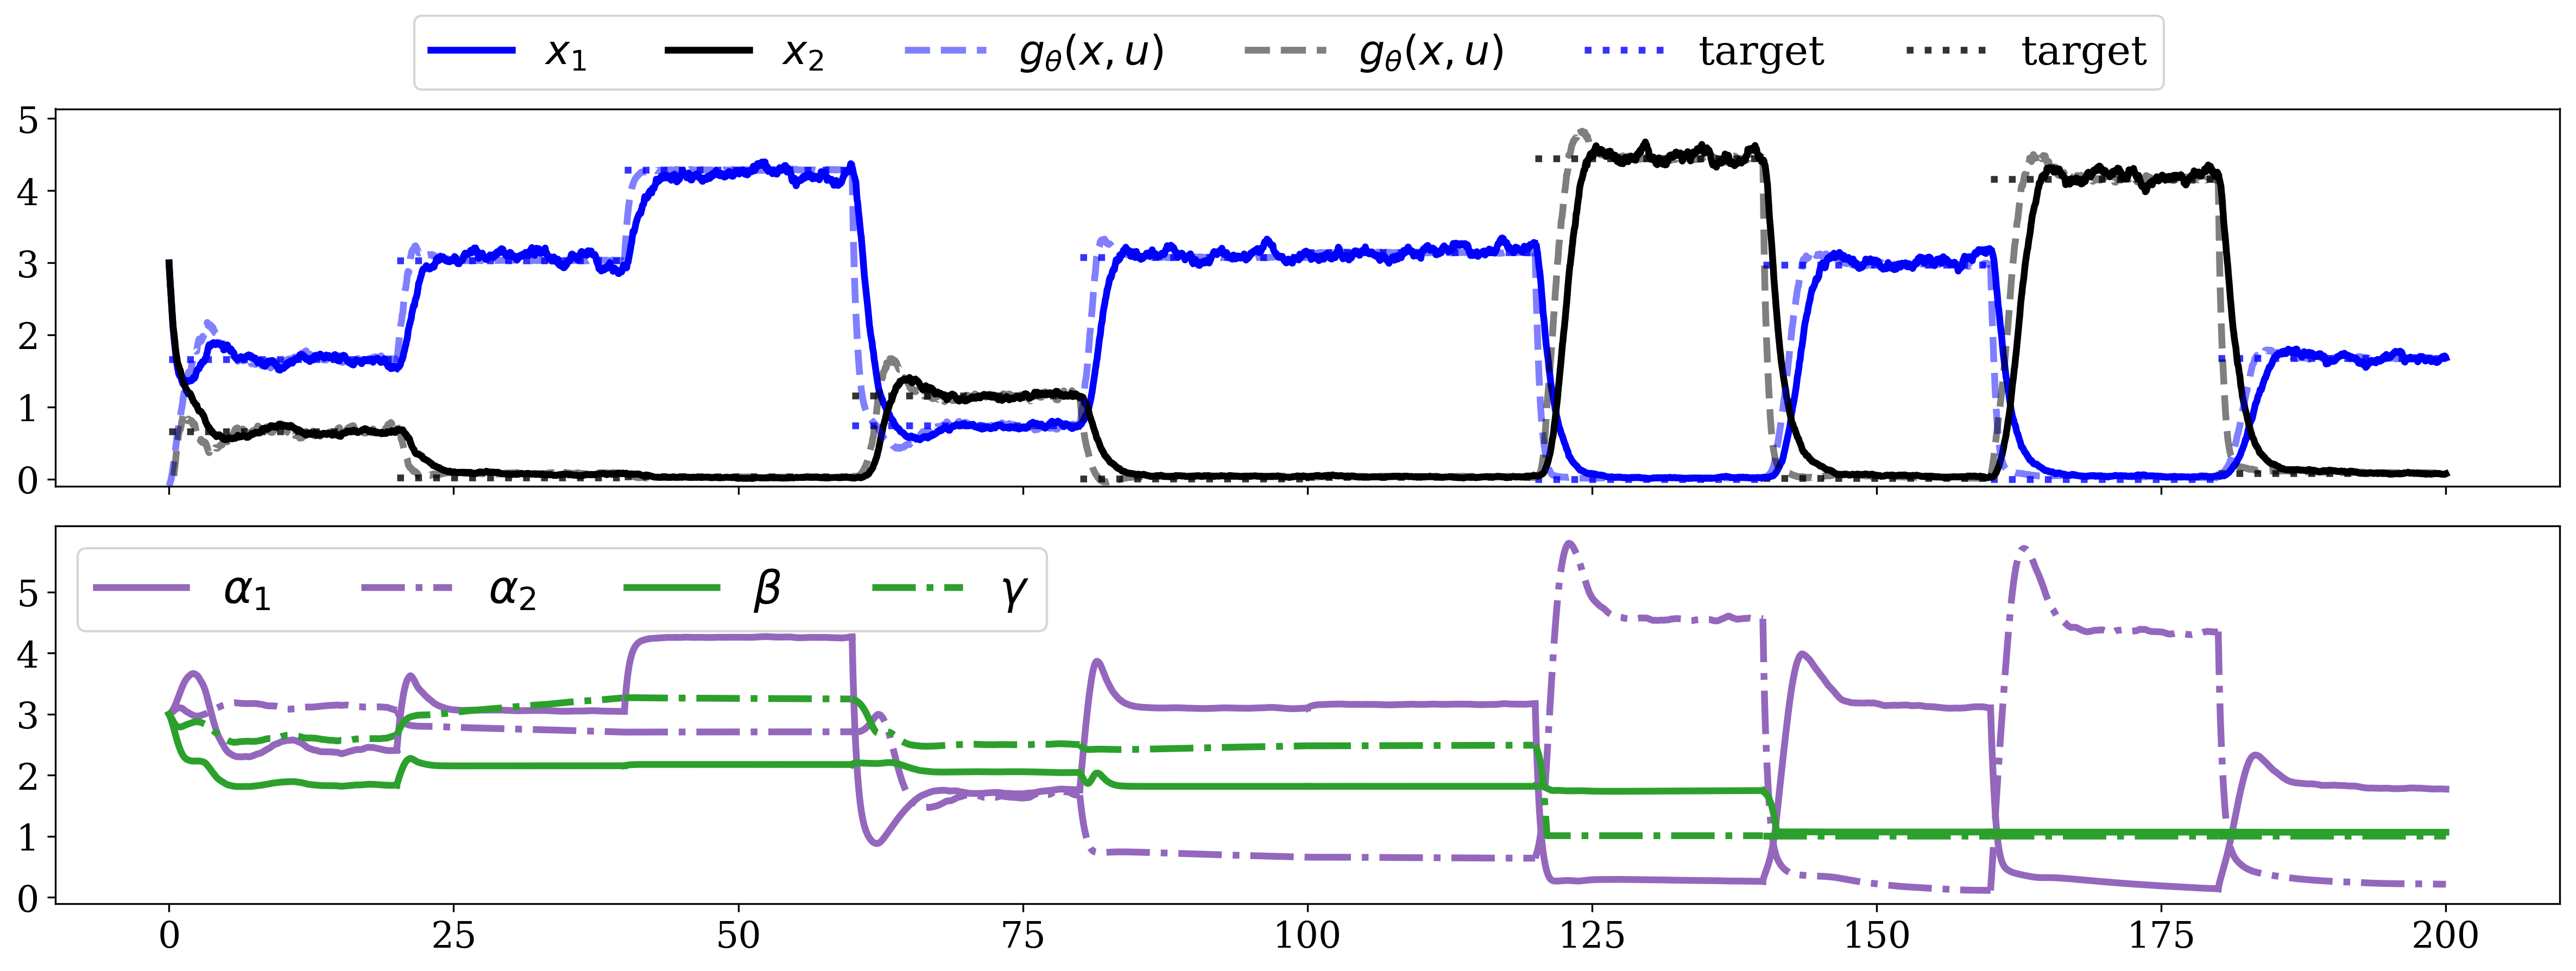

In [68]:
seed=42
# seed=9
seed=67
seed = 0
# np.random.seed(seed)
# rng = np.random.default_rng(seed=seed)

scale = 0.05
eta = 1e0
t_max = 20
k = 1

# 1. Lock Numpy (Keep this, covers sdeint and rng)
np.random.seed(seed)
rng = np.random.default_rng(seed=seed)

# 2. Lock PyTorch (Crucial for u_prime)
torch.manual_seed(seed)

# 3. Force Deterministic Algorithms 
# This ensures PyTorch uses reproducible algorithms where available
torch.use_deterministic_algorithms(True)


# acquire random targets

n_targets = 10
t=np.linspace(0,100,501)
x_targets = []



for idx in range(n_targets):
    u = rng.uniform(0,5,size=4)
    x0 = rng.uniform(0,6,size=2)

    sol = odeint(genetic_toggle_switch, x0,t,args=tuple(u))
    x_targets.append(sol[-1])



## solve stocastically 

xu0 = np.array([3,3,3,3,3,3])
t_span = np.linspace(0,t_max, n_colloc)
dt = t_span[1]-t_span[0]

Ts = []
Xs = []
Us = []
Xs_targets = []

noise_rng = np.random.default_rng(seed=seed)

for x_target in tqdm(x_targets):
    drift_term = make_drift_toggle(x_target,eta,k)
    diffusion_term = make_diffusion_toggle(scale)
    dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 2))

    sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
    X = sto_sol[:,:2]
    U = sto_sol[:,2:]
    xu0 = sto_sol[-1]

    Ts.append(t_span)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    xi=Xs[i]

    xi_tensor = torch.tensor(xi,dtype=torch.float32)
    ui_tensor = torch.tensor(ui, dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_tensor, ui_tensor)
    
    Gs.append(gi)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)



# print results 

fig, axs = plt.subplots(2,1, figsize=(16,6),sharex =True,dpi=300)

axs = axs.flatten()

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    ax = axs[0]
    if idx == 0:
        ax.plot(ti, Xsi[:,0],c='blue',zorder=2, label=r"$x_1$",lw=3)
        ax.plot(ti, Xsi[:,1],c='black',zorder=2,label=r"$x_2$",lw=3)
        ax.plot(ti,Gsi[:,0],c='blue', alpha=0.5, label=r"$g_\theta(x,u)$",lw=3,linestyle='--')
        ax.plot(ti,Gsi[:,1],c='black', alpha=0.5,label=r"$g_\theta(x,u)$",lw=3, linestyle='--')
    else:
        ax.plot(ti, Xsi[:,0],c='blue',zorder=2, lw=3)
        ax.plot(ti, Xsi[:,1],c='black',zorder=2,lw=3)
        ax.plot(ti,Gsi[:,0],c='blue', alpha=0.5,lw=3,linestyle='--')
        ax.plot(ti,Gsi[:,1],c='black', alpha=0.5,lw=3,linestyle='--')

    if idx == 0:
        ax.hlines(
            Xsi_target[0],
            xmin=ti[0],
            xmax=ti[-1],
            color='blue',
            alpha=0.8,
            linestyle=':',
            zorder=1,
            lw=3,
            label='target'
        )

        ax.hlines(
            Xsi_target[1],
            xmin=ti[0],
            xmax=ti[-1],
            color='black',
            alpha=0.8,
            linestyle=':',
            zorder=1,
            lw=3,
            label='target'
        )
    else: 
        ax.hlines(
            Xsi_target[0],
            xmin=ti[0],
            xmax=ti[-1],
            color='blue',
            alpha=0.8,
            linestyle=':',
            zorder=1,
            lw=3,
            # label='target'
        )

        ax.hlines(
            Xsi_target[1],
            xmin=ti[0],
            xmax=ti[-1],
            color='black',
            alpha=0.8,
            linestyle=':',
            zorder=1,
            lw=3,
            # label='target'
        )
    ax.legend(fontsize=18,ncols=6,bbox_to_anchor=(0.85,1.3))

    #control
    ax = axs[1]
    labs = [r"$\alpha_1$",r"$\alpha_2$",  r'$\beta$', r'$\gamma$']
    colors = ["red", "purple", "green",'orange']
    colors = ["purple", "green",'tab:orange',"tab:pink",]
    colors = ["purple", "green",'deeppink',"gray",]
    colors = ["tab:purple", "tab:purple",'tab:green',"tab:green",]
    alpha_colors = [1,1,1,1]
    linestyles = ['-','-.','-',"-."]

    for in_idx, u in enumerate(Usi.T):
        if idx==0:
            ax.plot(ti,u,c=colors[in_idx],alpha=alpha_colors[in_idx],label=labs[in_idx],lw=3,linestyle = linestyles[in_idx])
        else:
            ax.plot(ti,u,c=colors[in_idx],lw=3,alpha=alpha_colors[in_idx],linestyle = linestyles[in_idx])
        # print(u[-1])
        # print()
    ax.legend(fontsize=20,ncol=4,)

for ax in axs:
    
    # ax.set_xticks([0,1,2,3,4,5])
    ax.set_yticks([0,1,2,3,4,5])
    ax.tick_params(axis='both', which='major', labelsize=16, )
    # ax.grid(True)
    ax.set_ylim(-0.1)


plt.tight_layout()
plt.savefig("toggle-feedback-control.png")
plt.show()


    


# Big experiment (seeds = 0, ..., 99)

In [28]:
Xs = []
Xs_targets = []
errs = []
vars = []
stds = []

settling_ratio = 0.2 # Look at last 20% of the trajectory
n_colloc = 501
t_max = 20
eta=1e0
k=1
t_span = np.linspace(0,t_max,n_colloc)
scale = 0.05
dt = t_span[1]-t_span[0]


t = np.linspace(0,100,501)
seeds = [i for i in range(100)]

for seed in tqdm(seeds,unit="trial"):
    # print("Seed:", seed)
    rng = np.random.default_rng(seed)
    noise_rng = np.random.default_rng(seed)
    xu0 = np.array([3,3,3,3,3,3])


    for idx in range(n_targets,):
        # print("case:", idx)
        u = rng.uniform(0,5,size=4)
        x0 = rng.uniform(0,6,size=2)

        sol = odeint(genetic_toggle_switch, x0,t,args=tuple(u))
        x_target = sol[-1]
        
        drift_term = make_drift_toggle(x_target,eta,k)
        diffusion_term = make_diffusion_toggle(scale)
        dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 2))

        sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
        X = sto_sol[:,:2]
        U = sto_sol[:,2:]
        xu0 = sto_sol[-1]

        # Ts.append(t_span)
        Xs.append(X)
        # Us.append(U)
        Xs_targets.append(x_target)

        # get error and var
        n_steps = len(X)
        start_idx = int(n_steps * (1 - settling_ratio))
        steady_state = X[start_idx:,:]

        diff = np.abs(steady_state - x_target)
        err = np.linalg.norm(diff, axis=0) / np.sqrt(len(steady_state))
        var = np.var(diff,axis=0)
        stds.append(np.std(steady_state,axis=0))

        errs.append(err)
        vars.append(var)

errs = np.array(errs)
vars = np.array(vars)
stds = np.array(stds)
Xs_targets = np.array(Xs_targets)

  0%|          | 0/100 [00:00<?, ?trial/s]

In [29]:
errs = np.array(errs)
vars = np.array(vars)

np.mean(errs,axis=0), np.std(errs,axis=0), np.mean(vars,axis=0)

(array([0.05745974, 0.05275164]),
 array([0.0477016 , 0.04379038]),
 array([0.00085735, 0.00075871]))

In [62]:
np.count_nonzero(errs < 5*0.05,axis=0) / 1000

array([0.992, 0.994])

In [56]:
np.count_nonzero(errs < 5*0.02,axis=0) / 1000

array([0.853, 0.907])